In [1]:
import numpy as np
import math

E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
E:\anaconda3\envs\tensorflow\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
def tanh(x):
    return np.tanh(x)
def softmax(x):
    exp=np.exp(x-x.max())
    return exp/exp.sum()
#实现两个激活函数
#总体框架
#第0层 l` = A (input + b0)
#第1层output = A` (l` * w1 + b1)  两层网络输入28*28平展 l`有784个
#b0:784个
#b1:10个
#w1:[784 * 10]的矩阵

In [3]:
softmax(np.array([1,2,3,4]))

array([0.0320586 , 0.08714432, 0.23688282, 0.64391426])

In [4]:
dimensions=[28*28 , 10]
activation=[tanh,softmax] #激活函数
distribution=[
    {'b':[0,0]},
    {'b':[0,0],'w':[-math.sqrt(6/(dimensions[0]+dimensions[1])),math.sqrt(6/(dimensions[0]+dimensions[1]))]},
]
#初始化的区间
#第0层b 0 到 0
#第1层b 0 到 0
#第1层w -sqrt(6/(784+10)) 到 sqrt(6/(784+10))

In [5]:
def init_parameters_b(layer):
    dist = distribution[layer]['b']
    return np.random.rand(dimensions[layer])*(dist[1]-dist[0])+dist[0]
def init_parameters_w(layer):
    dist = distribution[layer]['w']
    return np.random.rand(dimensions[layer-1],dimensions[layer])*(dist[1]-dist[0])+dist[0]
#产生在区间dist0 到 dist1 的随机数，来辅助初始化
def init_parameters(): #把所有东西初始化
    parameter=[] #存放初始化后的所有数据
    for i in range(len(distribution)):
        layer_parameter={} #存放初始化后的单层数据
        for j in distribution[i].keys():
            if j == 'b':
                layer_parameter['b']=init_parameters_b(i)
                continue
            if j == 'w':
                layer_parameter['w']=init_parameters_w(i)
                continue
        parameter.append(layer_parameter)
    return parameter

In [6]:
init_parameters_b(0).shape
#第0层b

(784,)

In [7]:
init_parameters_b(1).shape
#第1层b

(10,)

In [8]:
init_parameters_w(1).shape
#第1层w

(784, 10)

In [9]:
parameters=init_parameters() #初始化的参数

In [10]:
def predict(img,parameters): #输入图片和参数
    l0_in = img + parameters[0]['b']
    l0_out=activation[0](l0_in)
    l1_in=np.dot(l0_out,parameters[1]['w'])+parameters[1]['b']  #内积
    l1_out = activation[1](l1_in)
    return l1_out
#前向传播

In [11]:
predict(np.random.rand(784),parameters).argmax() #随即输入，参数也是随机的

0

In [12]:
file_path = "C:\\Users\\haoran\\.keras\\datasets\\mnist.npz"

In [13]:
with np.load(file_path, allow_pickle=True) as data:
    train_image = data['x_train']
    train_label = data['y_train']
    test_image = data['x_test']
    test_label = data['y_test']

In [14]:
train_num=50000 #训练集 
valid_num=10000 #验证集 
test_num=10000  #测试集 
temp_image=train_image/ 255.0
test_image=train_image/ 255.0
temp_label=train_label
train_image=temp_image[:train_num]
valid_image=temp_image[train_num:]
train_label=temp_label[:train_num]
valid_label=temp_label[train_num:]

In [15]:
import matplotlib.pyplot as plt

In [16]:
def show_train(index):
    plt.imshow(train_image[index],cmap='gray')
    print('label:{}'.format(train_label[index]))
def show_valid(index):
    plt.imshow(valid_image[index],cmap='gray')
    print('label:{}'.format(valid_label[index]))
def show_test(index):
    plt.imshow(test_image[index],cmap='gray')
    print('label:{}'.format(test_label[index]))

label:5


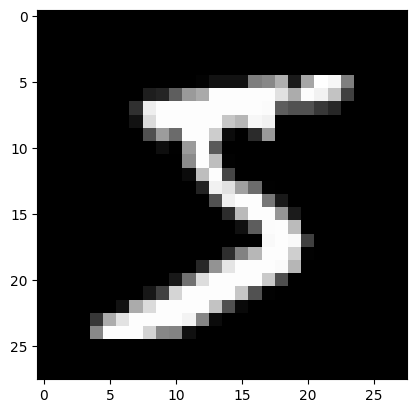

In [17]:
show_train(0)

label:8


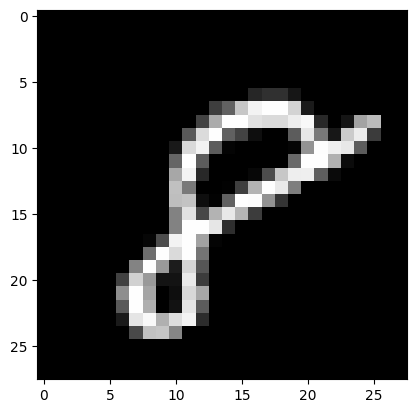

In [18]:
show_valid(9999)

In [19]:
np.outer([1,2,3,4],[5,6,7,8])

array([[ 5,  6,  7,  8],
       [10, 12, 14, 16],
       [15, 18, 21, 24],
       [20, 24, 28, 32]])

In [20]:
def d_softmax(data):
    sm=softmax(data)
    return np.diag(sm)-np.outer(sm,sm)  #softmax对角矩阵-softmax元素对应相乘
#softmax偏导数

In [21]:
#def d_tanh(data):
#    return np.diag(1/(np.cosh(data))**2) #只有对角线上有值
#tanh偏导数
def d_tanh(data):
    return 1/(np.cosh(data))**2 #向量

In [22]:
differential={softmax:d_softmax,tanh:d_tanh} #前key后value

In [23]:
d_tanh([1,2,3,4])

array([0.41997434, 0.07065082, 0.00986604, 0.00134095])

In [24]:
d_softmax(np.array([1,2,3,4]))

array([[ 0.03103085, -0.00279373, -0.00759413, -0.02064299],
       [-0.00279373,  0.07955019, -0.02064299, -0.05611347],
       [-0.00759413, -0.02064299,  0.18076935, -0.15253222],
       [-0.02064299, -0.05611347, -0.15253222,  0.22928869]])

In [25]:
onehot=np.identity(dimensions[-1]) #给一个10*10的独热矩阵

In [26]:
def sqr_loss(img,lab,parameters): #传入图片，标签，参数，计算损失
    y_pred=predict(img,parameters)
    y=onehot[lab]
    diff=y-y_pred
    return np.dot(diff,diff) #计算差值向量的元素平方和，等价于向量自身的点积

In [27]:
def grad_parameters(img,lab,parameters):
# 将28x28的图片展平为一维向量 (784,)
    img = img.flatten()
    
    l0_in = img + parameters[0]['b']
    l0_out=activation[0](l0_in)
    l1_in=np.dot(l0_out,parameters[1]['w'])+parameters[1]['b']  
    l1_out = activation[1](l1_in)
    
    diff=onehot[lab]-l1_out
    act1=np.dot(differential[activation[1]](l1_in),diff)
    
    grad_b1=-2*act1
    grad_w1=-2*np.outer(l0_out,act1)
    grad_b0=-2*differential[activation[0]](l0_in)*np.dot(parameters[1]['w'],act1) #向量乘后面的向量和转换成对角矩阵乘后面的向量结果一样。tanh偏导数的改变
    
    return{'w1':grad_w1,'b1':grad_b1,'b0':grad_b0}

In [28]:
grad_parameters(train_image[2],train_label[2],init_parameters())

{'w1': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'b1': array([ 0.0193078 ,  0.05242193,  0.03784602,  0.02726803, -0.24238006,
         0.02354424,  0.02258157,  0.02158687,  0.01861645,  0.01920715]),
 'b0': array([-2.35028432e-02, -1.05497900e-02, -8.48668883e-03,  3.20447192e-03,
        -6.25794315e-03,  4.48365603e-03,  1.67073618e-02, -8.85570140e-03,
         1.57872821e-02,  1.73676950e-03, -1.25637261e-02, -2.84634300e-02,
         1.26380881e-02, -9.32254749e-03, -1.86862101e-02, -1.88131013e-02,
         1.71716293e-02,  1.36207198e-02, -8.37683957e-03,  3.95978164e-03,
         1.02225950e-02,  1.44041410e-02, -1.55622102e-02, -9.96217149e-03,
         5.02613153e-03,  1.09978904e-02, -5.51594664e-03,  1.32002324e-02,
        -1.03000701e-02,  2.49619846e-02,  4.89075172

In [29]:
#用导数定义验证w1 
grad_list=[]
h=0.0001
for i in range(784):
    for j in range(10):
        img_i=np.random.randint(train_num)
        test_parameters=init_parameters()
        derivative=grad_parameters(train_image[img_i].flatten(),train_label[img_i],test_parameters)['w1']
        value1=sqr_loss(train_image[img_i].flatten(),train_label[img_i],test_parameters)
        test_parameters[1]['w'][i][j]+=h
        value2=sqr_loss(train_image[img_i].flatten(),train_label[img_i],test_parameters)
        grad_list.append(derivative[i][j]-(value2-value1)/h)
np.abs(grad_list).max()

4.825615205511502e-06

In [30]:
def valid_loss(parameters):
    loss_accu=0
    for img_i in range(valid_num):
        loss_accu+=sqr_loss(valid_image[img_i].flatten(),valid_label[img_i],parameters)
    return loss_accu/(valid_num/10000)
    #验证集损失值之和
def valid_accuracy(parameters):
    correct=[predict(valid_image[img_i].flatten(),parameters).argmax()==valid_label[img_i] for img_i in range(valid_num)]
    return correct.count(True)/len(correct)
    #验证集正确率
def train_loss(parameters):
    loss_accu=0
    for img_i in range(train_num):
        loss_accu+=sqr_loss(train_image[img_i].flatten(),train_label[img_i],parameters)
    return loss_accu/(train_num/10000)
    #验证集损失值之和
def train_accuracy(parameters):
    correct=[predict(train_image[img_i].flatten(),parameters).argmax()==train_label[img_i] for img_i in range(train_num)]
    return correct.count(True)/len(correct)
    #验证集正确率

In [31]:
train_loss(parameters)

9349.11386201206

In [32]:
batch_size=100 #一次性读取100张图片作为一组训练，组与组独立
def train_batch(current_batch,parameters):
    grad_accu=grad_parameters(
        train_image[current_batch*batch_size+0].flatten(),
        train_label[current_batch*batch_size+0],
        parameters
    )
    for img_i in range(1,batch_size):
        grad_tmp=grad_parameters(
            train_image[current_batch*batch_size+img_i].flatten(),
            train_label[current_batch*batch_size+img_i],
            parameters
        )
        for key in grad_accu.keys():
            grad_accu[key]+=grad_tmp[key]#100张图片梯度累加
    for key in grad_accu.keys():
        grad_accu[key]/=batch_size #求平均
    return grad_accu
    #得到这100张图片的平均的梯度

In [33]:
train_batch(0,parameters)

{'w1': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'b1': array([ 0.00770921, -0.01224795,  0.00423959, -0.00940824, -0.00856286,
         0.00425156,  0.00047847,  0.00227793,  0.01416324, -0.00290096]),
 'b0': array([ 5.88472323e-04, -1.72023075e-03,  5.32713363e-04, -8.66142470e-05,
        -5.26056946e-05,  4.61655838e-04, -1.09670932e-03, -2.52999908e-03,
        -5.34983168e-04,  7.59057974e-04,  1.15671526e-04, -9.50332424e-04,
        -1.40660297e-03,  1.47900153e-03,  9.78436346e-04, -1.37416220e-04,
         1.24516168e-03,  1.44509049e-04, -6.83989283e-04,  1.34934910e-03,
        -4.52566030e-04, -3.24069572e-04,  1.16775539e-03,  1.97218744e-03,
        -1.66563274e-03,  8.36774965e-04, -3.57584917e-04,  2.09701073e-03,
        -9.08839309e-04,  4.83072543e-04, -3.64454538

In [34]:
import copy
def combine_parameters(parameters,grad,learn_rate):
    parameter_tmp=copy.deepcopy(parameters) #深拷贝
    parameter_tmp[0]['b']-=learn_rate*grad['b0']
    parameter_tmp[1]['b']-=learn_rate*grad['b1']
    parameter_tmp[1]['w']-=learn_rate*grad['w1']
    return parameter_tmp
#更新参数

In [35]:
combine_parameters(parameters,train_batch(0,parameters),1)

[{'b': array([-5.88472323e-04,  1.72023075e-03, -5.32713363e-04,  8.66142470e-05,
          5.26056946e-05, -4.61655838e-04,  1.09670932e-03,  2.52999908e-03,
          5.34983168e-04, -7.59057974e-04, -1.15671526e-04,  9.50332424e-04,
          1.40660297e-03, -1.47900153e-03, -9.78436346e-04,  1.37416220e-04,
         -1.24516168e-03, -1.44509049e-04,  6.83989283e-04, -1.34934910e-03,
          4.52566030e-04,  3.24069572e-04, -1.16775539e-03, -1.97218744e-03,
          1.66563274e-03, -8.36774965e-04,  3.57584917e-04, -2.09701073e-03,
          9.08839309e-04, -4.83072543e-04,  3.64454538e-04,  5.33803336e-04,
         -1.08865482e-03, -1.34363445e-03, -1.02938053e-03,  5.31753716e-06,
          8.73904861e-04, -2.38226991e-03, -6.48758380e-04, -1.00051909e-03,
          1.09891632e-03, -1.97676054e-03,  1.12105609e-03,  1.00288832e-03,
         -1.28306376e-03, -6.27929510e-04,  6.49091835e-04,  1.18976619e-03,
          1.01508719e-04,  9.39443882e-04,  3.35903497e-04, -1.64814598

In [36]:
#开始训练
parameters=init_parameters() #初始化
current_epoch=0
train_loss_list=[]
valid_loss_list=[]
train_accu_list=[]
valid_accu_list=[]

In [37]:
valid_accuracy(parameters)

0.1031

In [38]:
learn_rate=1
epoch=5
for e in range(epoch):
    for i in range(train_num//batch_size):
        if i%100==99:
            print('running batch {}/{}'.format(i+1,train_num//batch_size))
        if i==499:
            print('已经训练完第',e+1,'个epoch')
        grad_tmp=train_batch(i,parameters)
        parameters=combine_parameters(parameters,grad_tmp,learn_rate)
    current_epoch+=1
    train_loss_list.append(train_loss(parameters))
    train_accu_list.append(train_accuracy(parameters))
    valid_loss_list.append(valid_loss(parameters))
    valid_accu_list.append(valid_accuracy(parameters))

running batch 100/500
running batch 200/500
running batch 300/500
running batch 400/500
running batch 500/500
已经训练完第 1 个epoch
running batch 100/500
running batch 200/500
running batch 300/500
running batch 400/500
running batch 500/500
已经训练完第 2 个epoch
running batch 100/500
running batch 200/500
running batch 300/500
running batch 400/500
running batch 500/500
已经训练完第 3 个epoch
running batch 100/500
running batch 200/500
running batch 300/500
running batch 400/500
running batch 500/500
已经训练完第 4 个epoch
running batch 100/500
running batch 200/500
running batch 300/500
running batch 400/500
running batch 500/500
已经训练完第 5 个epoch


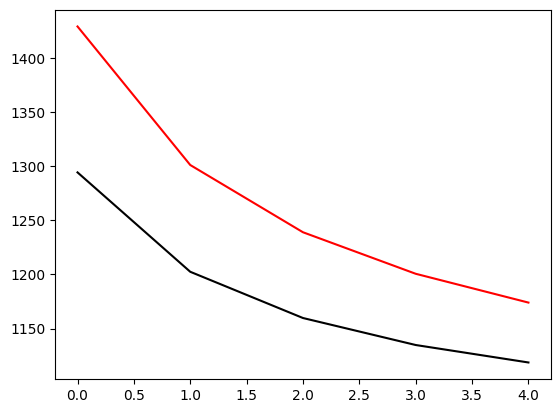

In [39]:
lower=0
plt.plot(valid_loss_list[lower:],color='black',label='validation loss')
plt.plot(train_loss_list[lower:],color='red',label='train loss')
plt.show()

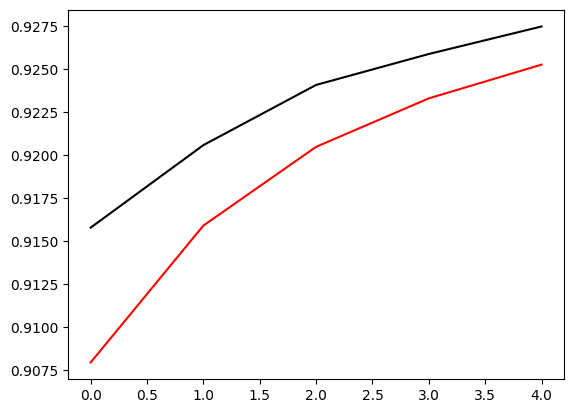

In [40]:
plt.plot(valid_accu_list[lower:],color='black',label='validation accuracy')
plt.plot(train_accu_list[lower:],color='red',label='train accuracy')
plt.show()

In [41]:
rand_batch=np.random.randint(train_num//batch_size)
grad_learn_rate=train_batch(rand_batch,parameters)

In [49]:
lr_list=[]
lower=-2  #10^lower
upper=0.1 #10^upper
step=0.1
for lr_pow in np.linspace(lower,upper,num=int((upper-lower)//step+1)):
    learn_rate=10**lr_pow
    parameters_tmp=combine_parameters(parameters,grad_learn_rate,learn_rate)
    train_loss_tmp=train_loss(parameters_tmp)
    lr_list.append([lr_pow,train_loss_tmp])

In [50]:
lr_list

[[-2.0, 1173.811154341605],
 [-1.895, 1173.7582598886238],
 [-1.79, 1173.6911053887259],
 [-1.685, 1173.6059192921698],
 [-1.58, 1173.4979785564879],
 [-1.475, 1173.361398245432],
 [-1.3699999999999999, 1173.1888946420415],
 [-1.265, 1172.9715340220312],
 [-1.16, 1172.6984946963055],
 [-1.055, 1172.356897261029],
 [-0.95, 1171.9318052910037],
 [-0.845, 1171.4065794081425],
 [-0.7399999999999998, 1170.7639040716736],
 [-0.6349999999999998, 1169.9880356885442],
 [-0.5299999999999998, 1169.0692047461541],
 [-0.4249999999999998, 1168.0117478427915],
 [-0.31999999999999984, 1166.8486244482062],
 [-0.21499999999999986, 1165.6667913074846],
 [-0.10999999999999988, 1164.6509940661701],
 [-0.004999999999999893, 1164.158836218719],
 [0.1, 1164.849242282266]]

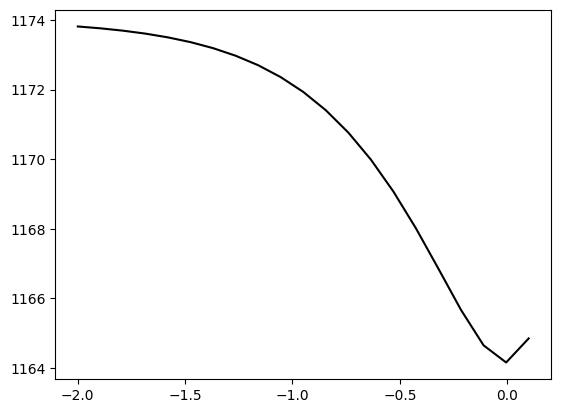

In [52]:
plt.plot(np.array(lr_list)[:,0],np.array(lr_list)[:,1],color='black')
plt.show()
#学习率从10^lower 到10^upper取，他的loss值分别为多少